In [2]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.base import BaseEstimator
from sklearn.linear_model import RidgeClassifier
from sklearn import svm

from tqdm.notebook import tqdm

### Набор данных с кристаллизацией

In [3]:
crys_df = pd.read_excel("lysozyme.xlsx")
crys_df = crys_df[["precipitater", "crystallization", "R", "dimer", "octamer"]]
crys_df.index = crys_df["precipitater"]
crys_df.drop("precipitater", axis=1, inplace=True)
crys_df.head()

,crystallization,R,dimer,octamer
precipitater,,,,
1_1,нет,14.3,0.0,0.0
1_10,нет,15.5,9.3,0.0
1_11,нет,15.0,5.4,0.0
1_13,нет,14.3,0.0,0.0
1_14,нет,14.3,0.0,0.0


### Спектры

In [4]:
# создаем словарь, где ключ - это id объекта, а значение - таблица с углами и интенсивностями
spectr_dir_root = "lysozyme_saxs/"
spectr_rows = 2578
skiprows = 3

spectr_df = {}
for file in os.listdir(spectr_dir_root):
    spec = pd.read_csv(os.path.join(spectr_dir_root, file), skiprows=skiprows, 
                       names=["scattering_angle", "intensity", "err"], 
                       nrows=spectr_rows, sep=" ", skipinitialspace=True)
    name_splitted = file.split("_")
    spectr_df[name_splitted[1][-1] + "_" + name_splitted[2]] = spec.drop("err", axis=1)

In [5]:
# Проверка на одинаковость углов (чтобы потом склеить все интенсивности)
template = np.array(spectr_df["1_1"]["scattering_angle"])
for obj_idx in spectr_df.keys():
    if np.any(template != np.array(spectr_df[obj_idx]["scattering_angle"])):
        print(obj_idx)

1_13
1_16
1_23
1_61
2_19


In [6]:
spectr_df["1_61"] # на одну запись меньше (другие также надо проверить)

,scattering_angle,intensity
0,1.496580e-01,1.666831e-02
1,1.524400e-01,1.643593e-02
2,1.552220e-01,1.652003e-02
3,1.580030e-01,1.690230e-02
4,1.607850e-01,1.644929e-02
...,...,...
2573,7.307080e+00,5.971450e-05
2574,7.309860e+00,-4.783830e-04
2575,7.312650e+00,6.471455e-04
2576,7.315430e+00,6.625720e-04


In [7]:
spectr_df["1_1"] # не хватает именно последнего значения для угла 7.318210. Удалим во всех таблицах

,scattering_angle,intensity
0,0.149658,0.016250
1,0.152440,0.015911
2,0.155222,0.015469
3,0.158003,0.016117
4,0.160785,0.015550
...,...,...
2573,7.307080,0.000300
2574,7.309860,-0.000509
2575,7.312650,0.000669
2576,7.315430,0.000504


In [8]:
# удаляем последнюю строку и переводим во float из object
for obj_idx in spectr_df.keys():
    spectr_df[obj_idx] = spectr_df[obj_idx].iloc[:-1].astype(float)

In [9]:
# Проверка на одинаковость углов
template = np.array(spectr_df["1_1"]["scattering_angle"])
for obj_idx in spectr_df.keys():
    if np.any(template != np.array(spectr_df[obj_idx]["scattering_angle"])):
        print(obj_idx)

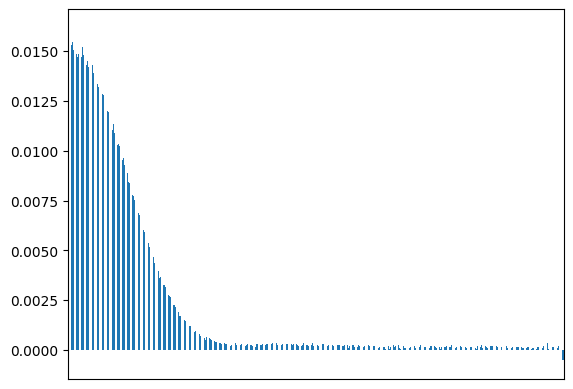

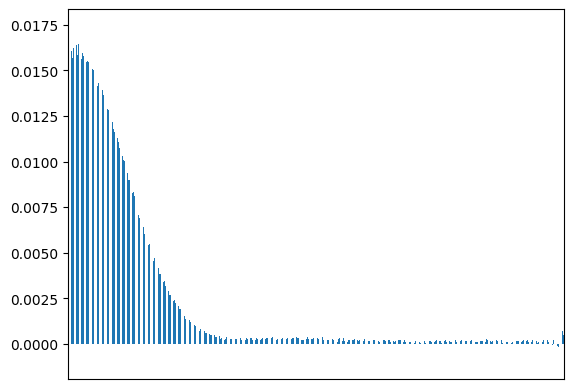

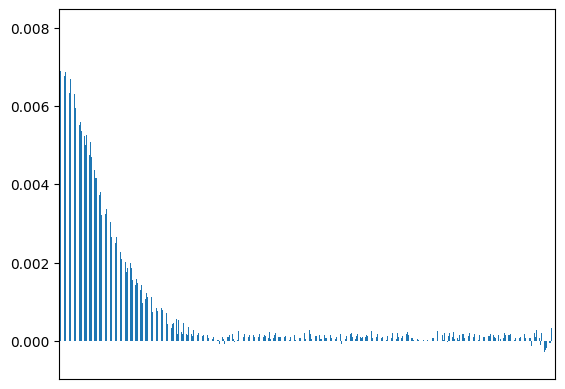

In [10]:
# построим графики для проверки. Похоже на спектр.
for i in ["1_1", "1_13", "2_19"]:
    spectr_df[i]["intensity"].plot.bar(xticks=[])
    plt.show()

In [11]:
intensity_lst = []
id_lst = []

for obj_idx in spectr_df.keys():
    spectr_df[obj_idx].drop("scattering_angle", axis=1, inplace=True) # удаляем угол
    intensity_lst.append(spectr_df[obj_idx].T) # запихиваем все интенсивности в один список
    id_lst.append(obj_idx)

In [12]:
# склеиваем все интенсивности для каждого объекта в одну таблицу. Индексом ставим id кристалла
intensity_df = pd.concat(intensity_lst)
intensity_df.index = id_lst
intensity_df.head()

,0,1,2,3,4,5,6,7,8,9,...,2567,2568,2569,2570,2571,2572,2573,2574,2575,2576
1_10,0.015204,0.015595,0.014513,0.015322,0.015911,0.016054,0.016275,0.016414,0.016364,0.016525,...,0.000354,-0.000526,0.000580,0.000166,0.000465,-0.000197,0.001208,-0.000295,-0.001411,-0.000061
1_11,0.019323,0.019261,0.019730,0.019324,0.018704,0.019049,0.019382,0.019100,0.018756,0.018227,...,-0.000352,-0.000044,-0.000442,-0.000224,-0.000141,-0.000200,0.000938,0.000285,-0.000714,0.000793
1_13,0.017424,0.017039,0.016708,0.016138,0.016734,0.017310,0.016568,0.017152,0.017331,0.016165,...,0.000347,0.000196,0.000694,-0.000483,-0.000056,0.000911,0.000445,0.000475,-0.000155,-0.000995
1_14,0.012603,0.012585,0.012807,0.012688,0.012501,0.012358,0.012127,0.012399,0.012862,0.012107,...,-0.000454,0.000445,-0.000407,0.000350,-0.000147,-0.000461,-0.000753,0.000183,-0.000301,-0.000997
1_15,0.015187,0.015511,0.015361,0.015478,0.015671,0.015139,0.015380,0.015419,0.015293,0.015504,...,-0.000285,-0.000243,0.000146,0.000221,-0.000565,-0.000096,-0.000321,0.000688,0.000112,-0.000591


In [13]:
df = intensity_df.join(crys_df) # собрали датасет воедино

### Обучение (Классификация)

In [14]:
# кодируем отклик
le = LabelEncoder()
le.fit(df["crystallization"])
df["crystallization"] = le.transform(df["crystallization"])

In [15]:
# разделяем отклик и признаки
X = df.drop(["crystallization", "dimer", "octamer", "R"], axis=1)
y = df["crystallization"]

In [16]:
# Кросс-валидационный accuracy для случайного леса
clf = RandomForestClassifier(random_state=123)
cvs = cross_val_score(clf, X, y, cv=5, scoring="accuracy")
print("accuracy:", cvs.mean())

accuracy: 0.6409090909090909


In [231]:
# upsampling можно сделать так и попробовать проверить, но для этого нужно отрезать тестовую выборку
# поэтому с таким небольшим датасетом я бы забил. Вряд ли будет польза.

# for cl in [0, 1, 2]:
#     rat = round(len(df[df['crystallization']==3])/len(df[df['crystallization']==cl])) - 1
#     if rat != 0:
#         df_up = df[df['crystallization']==cl]
#         df_up = df_up.loc[df_up.index.repeat(rat)]
#         df = pd.concat([df, df_up]).sample(frac=1)

In [19]:
# кросс-валидация на нейросети
clf = MLPClassifier((500, 500, 10), max_iter=1000, random_state=123)
cvs = cross_val_score(clf, X, y, cv=5, scoring="accuracy")
print("accuracy:", cvs.mean())

accuracy: 0.7121212121212122


In [17]:
# скалирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
# кросс-валидация на нейросети со скалированными признаками
clf = MLPClassifier((500, 500, 10), max_iter=1000, random_state=123)
cvs = cross_val_score(clf, X_scaled, y, cv=5, scoring="accuracy")
print("accuracy:", cvs.mean())

accuracy: 0.6409090909090909


In [20]:
# Метод снижения размерности
pca = PCA(n_components=50)
pca.fit(X_scaled)
pca.explained_variance_ratio_

array([7.70880544e-01, 1.83830413e-01, 1.03799226e-02, 9.33711004e-03,
       2.09390520e-03, 1.25567957e-03, 1.13137075e-03, 9.24118146e-04,
       8.61635995e-04, 8.39567527e-04, 7.96347594e-04, 7.69295040e-04,
       7.09892779e-04, 6.80615121e-04, 6.67870556e-04, 6.22933501e-04,
       6.13012734e-04, 5.81938756e-04, 5.62624286e-04, 5.52819439e-04,
       5.16048751e-04, 4.99438190e-04, 4.89498248e-04, 4.81529911e-04,
       4.74785459e-04, 4.54998591e-04, 4.42134513e-04, 4.31952680e-04,
       4.17316657e-04, 4.04107318e-04, 3.98003412e-04, 3.85930772e-04,
       3.75216946e-04, 3.52903869e-04, 3.42641983e-04, 3.42219898e-04,
       3.29647137e-04, 3.20641754e-04, 3.15997882e-04, 3.05273391e-04,
       2.99691014e-04, 2.94051537e-04, 2.87633988e-04, 2.78656403e-04,
       2.70643831e-04, 2.65819984e-04, 2.60895834e-04, 2.54683354e-04,
       2.44632725e-04, 2.43462150e-04])

In [26]:
# Применение PCA
pca = PCA(n_components=3, random_state=123)
X_pca = pca.fit_transform(X_scaled)

In [27]:
# Кросс-валидация на нейросети с данными из PCA
clf = MLPClassifier((5, 100, 60), max_iter=1000, random_state=123)
cvs = cross_val_score(clf, X_pca, y, cv=5, scoring="accuracy")
print("accuracy:", cvs.mean())

C:\Users\ПОЛЬЗОВАТЕЛЬ\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


accuracy: 0.6227272727272727


In [28]:
# посмотрим корреляции признаков с откликом
corrs = []
for col in X.columns:
    corrs.append((abs(np.corrcoef(X[col], y)[1][0]), col))

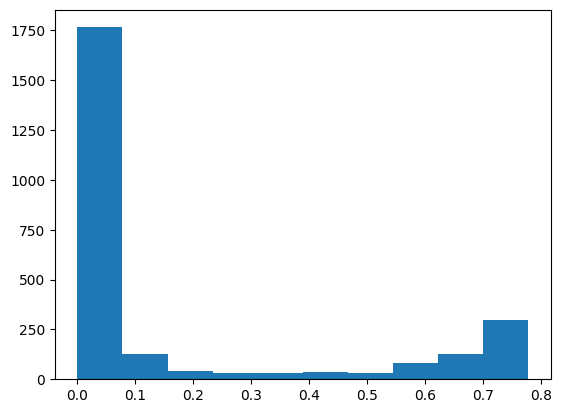

In [29]:
plt.hist(np.array(corrs)[:, 0])
plt.show()

In [30]:
# Берем только фичи, коррелирующие с откликом с корреляцией > 0.2
good_features = []
for corr, col in corrs:
    if corr > 0.2:
        good_features.append(col)

In [31]:
X_correlate = X[good_features] # можно брать фичи из X_scaled уже

In [32]:
# Кросс-валидация на нейросети с коррелирующими данными
clf = MLPClassifier((100, 10), max_iter=2000, random_state=123)
cvs = cross_val_score(clf, X_correlate, y, cv=5, scoring="accuracy")
print("accuracy:", cvs.mean())

C:\Users\ПОЛЬЗОВАТЕЛЬ\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\ПОЛЬЗОВАТЕЛЬ\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\ПОЛЬЗОВАТЕЛЬ\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


accuracy: 0.7303030303030303


C:\Users\ПОЛЬЗОВАТЕЛЬ\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
# пример подбора гиперпараметров на кросс-валидации
import warnings
warnings.filterwarnings("ignore")

history = []
# НУЖНО ПОДОБРАТЬ ДРУГИЕ ГИПЕРМАРАМЕТРЫ И СДЕЛАТЬ АДЕКВАТНЫЕ ДИАПОЗОНЫ
for i in tqdm(range(5, 100, 10)): # лучше до 100
    for j in range(5, 200, 10): # можно оставить
        for k in range(5, 100, 10): # лучше до 100
            reg = MLPClassifier((i, j, k), random_state=123, max_iter=1000)
            cvs = cross_val_score(reg, X_pca, y, cv=5, scoring="accuracy")
            mean_cvs = np.mean(cvs)
            history.append((np.abs(mean_cvs), i, j, k))

  0%|          | 0/20 [00:00<?, ?it/s]

In [ ]:
# топ 20 результатов подбора
sorted(history, reverse=True)[:20]

In [33]:
# другие модели
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=1,
    min_samples_split=2,
    criterion="entropy",
    random_state=123
)
cvs = cross_val_score(clf, X_pca, y, cv=5, scoring="accuracy")
print("accuracy:", cvs.mean())

accuracy: 0.6772727272727271


In [34]:
# другие модели
clf = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=6,
    criterion="entropy",
    random_state=123
)
cvs = cross_val_score(clf, X_pca, y, cv=5, scoring="accuracy")
print("accuracy:", cvs.mean())

accuracy: 0.5863636363636363


In [35]:
# другие модели
clf = KNeighborsClassifier(
    n_neighbors=6
)
cvs = cross_val_score(clf, X_pca, y, cv=5, scoring="accuracy")
print("accuracy:", cvs.mean())

accuracy: 0.6787878787878788


In [38]:
# делаем мультикласс при помощи моделей бинарной классификации

class MultiClassifier(BaseEstimator): #заведём свою модель - MultiClassifier
    def __init__(self, C=1): #Инициализация, сюда передаются те параметры, которые, используем MultiClassifier
        self.C = C
        self.clf1 = LogisticRegression(C=C)
        self.clf2 = LogisticRegression(C=C)
        self.clf3 = LogisticRegression(C=C)
        self.clf4 = LogisticRegression(C=C)
        
    def fit(self, X_train, Y_train):
        self.clf1.fit(X_train, Y_train==0) #Обучаем все модели под разные задачи бин. классификации
        self.clf2.fit(X_train, Y_train==1)
        self.clf3.fit(X_train, Y_train==2)
        self.clf4.fit(X_train, Y_train==3)
        
    def predict(self, X_test):
        pred1 = self.clf1.predict_proba(X_test)[:,1]
        pred2 = self.clf2.predict_proba(X_test)[:,1]
        pred3 = self.clf3.predict_proba(X_test)[:,1]
        pred4 = self.clf4.predict_proba(X_test)[:,1]
        
        return np.argmax(np.array([pred1, pred2, pred3, pred4]), axis=0)


#К переменной self нужно относиться, как к хранилищу. Туда мы можем сложить переменные, которые потом 
#можно вытащить в любой другой функции класса.

In [39]:
clf = MultiClassifier(C=3)
cvs = cross_val_score(clf, X_pca, y, cv=5, scoring="accuracy")
print("accuracy:", cvs.mean())

accuracy: 0.6924242424242425


In [40]:
# примерно то же самое, что и выше
clf = LogisticRegression(C=3, multi_class="ovr")
cvs = cross_val_score(clf, X_pca, y, cv=5, scoring="accuracy")
print("accuracy:", cvs.mean())

accuracy: 0.693939393939394


C:\Users\ПОЛЬЗОВАТЕЛЬ\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\ПОЛЬЗОВАТЕЛЬ\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\ПОЛЬЗОВАТЕЛЬ\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn

In [88]:
clf = svm.SVC(C=1, kernel="rbf")
cvs = cross_val_score(clf, X, y, cv=5, scoring="accuracy")
print("accuracy:", cvs.mean())

accuracy: 0.6636363636363637


In [37]:
clf = RidgeClassifier(alpha=3)
cvs = cross_val_score(clf, X, y, cv=5, scoring="accuracy")
print("accuracy:", cvs.mean())

accuracy: 0.4636363636363637


# Обучение (регрессия)

In [41]:
# предсказываю R. Можно пробовать другие модели.
y = df["R"]

In [42]:
clf = RandomForestRegressor(
    n_estimators=200,
    max_depth=2,
    random_state=123
)
cvs = cross_val_score(clf, X, y, cv=5, scoring="neg_root_mean_squared_error")
print("RMSE:", abs(cvs).mean())

RMSE: 2.178480554427537


In [43]:
clf = RandomForestRegressor(
    n_estimators=200,
    max_depth=2,
    random_state=123
)
cvs = cross_val_score(clf, X_correlate, y, cv=5, scoring="neg_root_mean_squared_error")
print("RMSE:", abs(cvs).mean())

RMSE: 2.0954385516963674


In [44]:
clf = LinearRegression()
cvs = cross_val_score(clf, X_scaled, y, cv=5, scoring="neg_root_mean_squared_error")
print("RMSE:", abs(cvs).mean())

RMSE: 1.4748199837849052


In [45]:
clf = KNeighborsRegressor(n_neighbors=6)
cvs = cross_val_score(clf, X_pca, y, cv=5, scoring="neg_root_mean_squared_error")
print("RMSE:", abs(cvs).mean())

RMSE: 1.9142671586863926


In [46]:
clf = MLPRegressor((30, 40, 10), max_iter=3000, random_state=123)
cvs = cross_val_score(clf, X_correlate, y, cv=5, scoring="neg_root_mean_squared_error")
print("RMSE:", abs(cvs).mean())

C:\Users\ПОЛЬЗОВАТЕЛЬ\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(


RMSE: 5.407354111732665


## Совет для Даши

Новые признаки, которые стоит попробовать:
1) Максимальное/минимальное/среднее/дисперсия/различные квантили значение интенсивности; \
2) Угол рассеивания с максимальной/минимальной интенсивностью; \
3) и т. д.

In [47]:
# создаем словарь, где ключ - это id объекта, а значение - таблица с углами и интенсивностями
spectr_dir_root = "lysozyme_saxs/"
spectr_rows = 2578
skiprows = 3

spectr_df = {}
for file in os.listdir(spectr_dir_root):
    spec = pd.read_csv(os.path.join(spectr_dir_root, file), skiprows=skiprows, 
                       names=["scattering_angle", "intensity", "err"], 
                       nrows=spectr_rows, sep=" ", skipinitialspace=True)
    name_splitted = file.split("_")
    spectr_df[name_splitted[1][-1] + "_" + name_splitted[2]] = spec.drop("err", axis=1)
    
# удаляем последнюю строку и переводим во float из object
for obj_idx in spectr_df.keys():
    spectr_df[obj_idx] = spectr_df[obj_idx].iloc[:-1].astype(float)

In [48]:
features = []
idxs = []
for obj_idx in spectr_df.keys():
    obj_feature = []
    idxs.append(obj_idx)
    obj_feature.append(spectr_df[obj_idx]["intensity"].max())
    obj_feature.append(spectr_df[obj_idx]["intensity"].min())
    obj_feature.append(spectr_df[obj_idx]["intensity"].mean())
    obj_feature.append(spectr_df[obj_idx]["intensity"].var())
    for q in np.linspace(0.1, 0.9, 9):
        obj_feature.append(spectr_df[obj_idx]["intensity"].quantile(q))
    features.append(obj_feature)

In [49]:
feature_eng = pd.DataFrame(features, index=idxs)

In [50]:
df_eng = feature_eng.join(crys_df)

In [51]:
le = LabelEncoder()
le.fit(df_eng["crystallization"])
df_eng["crystallization"] = le.transform(df_eng["crystallization"])

# разделяем отклик и признаки
X = df_eng.drop(["crystallization", "dimer", "octamer", "R"], axis=1)
y = df_eng["crystallization"]

# кросс-валидация на RF
clf = RandomForestClassifier(random_state=123)
cvs = cross_val_score(clf, X, y, cv=5, scoring="accuracy")
print("accuracy:", cvs.mean())

accuracy: 0.5878787878787879
